In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import os
import cv2

In [2]:
!pip install roboflow torchvision albumentations -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 83.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 139.6 MB/s eta 0:00:00


In [3]:
from roboflow import Roboflow
rf = Roboflow(api_key="FubcSJVDHEnV0FhKPMWy")
project = rf.workspace("nguyns-workspace-th4ak").project("dengue-fever-detection")
version = project.version(2)
dataset = version.download("coco")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to dengue-fever-detection-2 in coco:: 100%|██████████| 9703/9703 [00:02<00:00, 3900.37it/s]


In [4]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

def get_transforms(train=True):
    # Sử dụng format 'yolo' đồng nhất
    # YOLO format: [x_center, y_center, width, height] chuẩn hóa 0-1
    bbox_params = A.BboxParams(
        format='yolo',
        label_fields=['labels'],
        min_visibility=0.1, # Loại bỏ các box quá nhỏ sau khi augment
        clip=True
    )
    if train:
        return A.Compose([
            A.Resize(512, 512),
            A.HorizontalFlip(p=0.5),
            A.RandomBrightnessContrast(p=0.3),
            A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.3),
            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ToTensorV2()
        ], bbox_params=bbox_params)
    else:
        return A.Compose([
            A.Resize(512, 512),
            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ToTensorV2()
        ], bbox_params=bbox_params)

In [5]:
import cv2
import numpy as np
import torch
from torchvision.datasets import CocoDetection
from torchvision.transforms import ToTensor

class RoboflowDetection(CocoDetection):
    def __init__(self, img_folder, ann_file, transforms=None):
        super().__init__(img_folder, ann_file)
        self.transforms = transforms

        # Ánh xạ ID của COCO sang Label liên tục (0, 1, 2...)
        cats = self.coco.cats
        self.cat_id_to_label = {
            cat_id: i for i, cat_id in enumerate(sorted(cats.keys()))
        }

        # Map ngược để hiển thị tên class khi inference
        self.label_to_name = {
            i: self.coco.cats[cat_id]['name']
            for i, cat_id in enumerate(sorted(cats.keys()))
        }

    def __getitem__(self, idx):
        # 1. Lấy thông tin ảnh và annotation
        img_id = self.ids[idx]
        img_info = self.coco.loadImgs(img_id)[0]
        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        annotations = self.coco.loadAnns(ann_ids)

        # 2. Đọc ảnh (Nên dùng OpenCV để đồng bộ với Albumentations)
        img_path = os.path.join(self.root, img_info['file_name'])
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        orig_h, orig_w = img.shape[:2]

        # 3. Chuẩn bị Boxes và Labels
        boxes = []
        labels = []
        for obj in annotations:
            if "bbox" not in obj or obj.get('iscrowd', 0):
                continue
            x, y, w, h = obj["bbox"]
            # Convert COCO (xmin, ymin, w, h) -> YOLO Normalized (x_c, y_c, w, h)
            x_center = (x + w / 2) / orig_w
            y_center = (y + h / 2) / orig_h
            nw = w / orig_w
            nh = h / orig_h

            # kiểm tra giá trị hợp lệ
            if nw > 1e-4 and nh > 1e-4:
              boxes.append([x_center, y_center, nw, nh])
              labels.append(self.cat_id_to_label[obj["category_id"]])

        # 4. Áp dụng Transforms (Albumentations)
        if self.transforms:
            # Rất quan trọng: labels phải được truyền vào đúng tên tham số đã định nghĩa trong BboxParams
            transformed = self.transforms(image=img, bboxes=boxes, labels=labels)
            img = transformed["image"]
            boxes = torch.tensor(transformed["bboxes"], dtype=torch.float32)
            labels = torch.tensor(transformed["labels"], dtype=torch.int64)
        else:
            # Nếu không có transforms, chỉ convert sang Tensor
            img = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)

        # 5. Xử lý trường hợp không có box nào (Empty Image)
        if boxes.numel() == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([idx])
        }

        return img, target

In [6]:
def collate_fn(batch):
    return tuple(zip(*batch))

In [7]:
from torch.utils.data import DataLoader

train_dataset = RoboflowDetection(
    img_folder=os.path.join(dataset.location, "train"),
    ann_file=os.path.join(dataset.location, "train/_annotations.coco.json"),
    transforms=get_transforms(train=True)
)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2,
    collate_fn=collate_fn,
    pin_memory=True
)

print("Dataset size:", len(train_dataset))

loading annotations into memory...
Done (t=0.07s)
creating index...
index created!
Dataset size: 9300


In [8]:
images, targets = next(iter(train_loader))

print("Batch size:", len(images))
print("Image shape:", images[0].shape)
print("Boxes:", targets[0]["boxes"])
print("Labels:", targets[0]["labels"])

Batch size: 16
Image shape: torch.Size([3, 512, 512])
Boxes: tensor([], size=(0, 4))
Labels: tensor([], dtype=torch.int64)


In [9]:
import numpy as np

def get_wh(dataset):
    """
    Đọc trực tiếp từ COCO annotation thay vì chạy __getitem__
    → Nhanh hơn vì không cần apply transforms
    """
    wh = []
    coco = dataset.coco
    for ann in coco.dataset['annotations']:
        if ann.get('iscrowd', 0):
            continue
        img_info = coco.imgs[ann['image_id']]
        W, H = img_info['width'], img_info['height']
        _, _, w, h = ann['bbox']
        nw, nh = w / W, h / H
        if nw > 1e-4 and nh > 1e-4:
            wh.append([nw, nh])
    return np.array(wh)

def iou_wh(box, clusters):
    w, h = box
    cw, ch = clusters[:, 0], clusters[:, 1]
    inter = np.minimum(w, cw) * np.minimum(h, ch)
    union = w*h + cw*ch - inter
    return inter / (union + 1e-6)

def kmeans_anchors(boxes, k=3, iters=20):
    clusters = boxes[np.random.choice(len(boxes), k, replace=False)]

    for _ in range(iters):
        assignments = []
        for b in boxes:
            ious = iou_wh(b, clusters)
            assignments.append(np.argmax(ious))
        assignments = np.array(assignments)

        new_clusters = []
        for i in range(k):
            cluster = boxes[assignments == i]
            if len(cluster) == 0:
                new_clusters.append(clusters[i])
            else:
                new_clusters.append(np.mean(cluster, axis=0))
        if np.allclose(clusters, new_clusters, atol=1e-6):
            break
        clusters = np.array(new_clusters)

    # Sort anchors theo diện tích tăng dần
    clusters = clusters[np.argsort(clusters[:, 0] * clusters[:, 1])]
    return clusters

In [10]:
wh = get_wh(train_dataset)
anchors = kmeans_anchors(wh, k=3)
print("Anchors (w,h):", anchors)

Anchors (w,h): [[0.20020389 0.20243554]
 [0.48899822 0.49024646]
 [0.81949249 0.8318862 ]]


In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class VGG16(nn.Module): #Encoder: đưa img về feature vector
    def __init__(self, embedding_dim=512):
        super(VGG16, self).__init__()

        # Thêm BatchNorm để training ổn định hơn
        def conv_bn_relu(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True)
            )

        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2,2),

            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2,2),

            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1), nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2,2),

            nn.Conv2d(256, 512, 3, padding=1), nn.ReLU(),
            nn.Conv2d(512, 512, 3, padding=1), nn.ReLU(),
            nn.Conv2d(512, 512, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2,2),

            nn.Conv2d(512, 512, 3, padding=1), nn.ReLU(),
            nn.Conv2d(512, 512, 3, padding=1), nn.ReLU(),
            nn.Conv2d(512, 512, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2,2),
        )
        # Fix kích thước output về 7x7 tránh phụ thuộc input size
        self.avgpool = nn.AdaptiveAvgPool2d((7, 7))

        # Đưa feature về embedding vector
        self.fc1 = nn.Linear(512*7*7, 4096)
        self.fc2 = nn.Linear(4096, 4096)
        self.embedding = nn.Linear(4096, embedding_dim)

        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        feat = self.features(x) #(B, 512, 20, 20)
        x = self.avgpool(feat)
        x = torch.flatten(x, 1)

        x = self.dropout(F.relu(self.fc1(x)))
        x = self.dropout(F.relu(self.fc2(x)))

        emb = self.embedding(x)
        emb = F.normalize(emb, p=2, dim=1)

        return feat, emb

In [12]:
class DetectionHead(nn.Module):
    def __init__(self, in_ch, num_classes, num_anchors):
        super().__init__()
        self.num_anchors = num_anchors
        self.num_classes = num_classes
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, 256, 3, padding=1),
            nn.BatchNorm2d(256),           # BatchNorm
            nn.ReLU(inplace=True)
        )
        self.pred = nn.Conv2d(256, num_anchors * (5 + num_classes), 1)
    def forward(self, x):
        x = F.relu(self.conv(x))
        x = self.pred(x)              # (B, A*(5+C), S, S)
        B, _, S, _ = x.shape
        x = x.reshape(B, self.num_anchors, 5 + self.num_classes, S, S)
        # Permute về (B, A, S, S, 5+C)
        x = x.permute(0, 1, 3, 4, 2).contiguous()
        return x

In [13]:
class VGGDetector(nn.Module):
    def __init__(self, num_classes, num_anchors):
        super().__init__()
        self.backbone = VGG16()
        self.head = DetectionHead(512, num_classes, num_anchors)
    def forward(self, x):
        feat, _ = self.backbone(x)
        return self.head(feat)  # → (B, A, S, S, 5+C)

In [14]:
def build_targets(pred_shape, target_boxes, target_labels, anchors, num_classes, device):
    """anchors truyền vào là anchors GỐC (0-1 normalized),
        không là scaled_anchors, vì box[2:4] cũng ở scale 0-1.
        Scale sẽ chỉ được dùng khi tính tw, th."""
    B, A, S, _, _ = pred_shape

    # Khởi tạo target tensors cho MỘT hình
    obj_mask = torch.zeros((A, S, S), device=device)
    tx = torch.zeros_like(obj_mask)
    ty = torch.zeros_like(obj_mask)
    tw = torch.zeros_like(obj_mask)
    th = torch.zeros_like(obj_mask)
    tcls = torch.zeros((A, S, S, num_classes), device=device)

    # Nếu hình không có box nào, trả về mask rỗng (toàn 0)
    if target_boxes.shape[0] == 0:
        return obj_mask, tx, ty, tw, th, tcls

    # Duyệt qua từng box trong hình đó
    for box, cls in zip(target_boxes, target_labels):
        cx_s = box[0] * S  # x center trong grid
        cy_s = box[1] * S  # y center trong grid
        gi   = int(cx_s.clamp(0, S - 1))
        gj   = int(cy_s.clamp(0, S - 1))

        # iou_wh dùng anchors CÙNG SCALE với box (đều 0-1 normalized)
        ious   = iou_wh(box[2:4].cpu().numpy(), anchors.cpu().numpy())
        best_a = int(np.argmax(ious))

        # Tìm anchor tốt nhất (dựa trên w, h)
        # box[2:4] là [w, h] chuẩn hóa 0-1, anchors cũng chuẩn hóa 0-1
        ious = iou_wh(box[2:4].cpu().numpy(), anchors.cpu().numpy())
        best_a = np.argmax(ious)

        obj_mask[best_a, gj, gi] = 1.0
        tx[best_a, gj, gi] = cx_s - gi # Offset x
        ty[best_a, gj, gi] = cy_s - gj # Offset y
        # tw, th: log offset so với anchor (anchors ở scale 0-1)
        tw[best_a, gj, gi] = torch.log(box[2] / anchors[best_a][0] + 1e-9)
        th[best_a, gj, gi] = torch.log(box[3] / anchors[best_a][1] + 1e-9)
        tcls[best_a, gj, gi, cls.long()] = 1.0

    return obj_mask, tx, ty, tw, th, tcls

In [15]:
def focal_loss(pred, target, alpha=0.25, gamma=2.0):
    """
    Focal Loss giảm weight cho easy examples (confident predictions)
    """
    ce_loss = F.binary_cross_entropy(pred, target, reduction='none')
    p_t = pred * target + (1 - pred) * (1 - target)
    focal_loss = alpha * (1 - p_t) ** gamma * ce_loss
    return focal_loss.mean()

def yolo_loss(pred_single, target_data, anchors, num_classes,
              lambda_obj=1.0, lambda_noobj=100.0, lambda_box=5.0, lambda_cls=1.0):
    """
    Thêm lambda_noobj để giảm penalty cho background cells
    pred_single: (A, S, S, 5+C)
    """
    obj_mask, tx, ty, tw, th, tcls = target_data

    # 1. Trích xuất các thành phần dự đoán
    # pred_single shape: (A, S, S, 5+C)
    pred_x   = torch.sigmoid(pred_single[..., 0])
    pred_y   = torch.sigmoid(pred_single[..., 1])
    pred_w   = pred_single[..., 2] # log space
    pred_h   = pred_single[..., 3] # log space
    pred_obj = torch.sigmoid(pred_single[..., 4])
    pred_cls = pred_single[..., 5:] # logit space

    # 2. Mask để chỉ tính toán tại những ô có vật thể
    mask = obj_mask.bool() # Shape: (A, S, S)
    no_mask = ~mask

    # 3. Objectness Loss (Tính trên toàn bộ Grid)
    # Cần đảm bảo obj_mask có cùng shape với pred_obj (A, S, S)
    # Tách objectness loss thành obj và noobj
    loss_obj   = lambda_obj   * focal_loss(pred_obj[mask],    obj_mask[mask])    if mask.sum() > 0 else 0
    loss_noobj = lambda_noobj * focal_loss(pred_obj[no_mask], obj_mask[no_mask]) if no_mask.sum() > 0 else 0

    loss_box = 0
    loss_cls = 0

    if mask.sum() > 0:
        # 4. Bounding Box Loss (Chỉ tính nơi có mask)
        loss_x = F.mse_loss(pred_x[mask], tx[mask])
        loss_y = F.mse_loss(pred_y[mask], ty[mask])
        loss_w = F.mse_loss(pred_w[mask], tw[mask])
        loss_h = F.mse_loss(pred_h[mask], th[mask])
        loss_box = lambda_box * (loss_x + loss_y + loss_w + loss_h)

        # 5. Classification Loss
        # tcls[mask] shape: (N, num_classes), pred_cls[mask] shape: (N, num_classes)
        loss_cls = lambda_cls * F.binary_cross_entropy_with_logits(pred_cls[mask], tcls[mask])

    return loss_obj + loss_noobj + loss_box + loss_cls

In [16]:
num_classes = len(train_dataset.cat_id_to_label)
num_anchors = len(anchors) # Đảm bảo khớp với số lượng anchor đã tính

model = VGGDetector(num_classes, num_anchors).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

# Learning rate scheduler giảm LR khi loss plateau
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

# Đưa anchors về tensor và chuẩn hóa (nếu anchors đang ở dạng pixel, chia cho 640)
anchors_tensor = torch.tensor(anchors, dtype=torch.float32).to(device)

for epoch in range(20):
    model.train()
    epoch_loss = 0

    for batch_idx, (imgs, targets) in enumerate(train_loader):
        # 1. Chuẩn bị dữ liệu batch
        imgs = torch.stack(imgs).to(device)
        # 2. Forward pass
        # pred shape sau khi forward: (B, A, S, S, 5+C)
        pred = model(imgs)
        B, A, S, _, C = pred.shape

        # 3. Tính toán Target và Loss
        # Lưu ý: Ta vẫn dùng vòng lặp cho build_targets vì logic gán box vào grid khá phức tạp,
        # nhưng ta tối ưu bằng cách gom loss lại tính một lần.
        total_batch_loss = 0

        for i in range(B):
            # Lấy ground truth của hình thứ i trong batch
            target_boxes = targets[i]["boxes"].to(device)
            target_labels = targets[i]["labels"].to(device)

            # Xây dựng target tensor cho hình này
            target_data = build_targets(
                pred.shape, # truyền shape để biết S, A
                target_boxes,
                target_labels,
                anchors_tensor,
                num_classes,
                device
            )

            # Tính loss cho hình thứ i
            total_batch_loss += yolo_loss(pred[i], target_data, anchors_tensor, num_classes)

        loss = total_batch_loss / B  # Trung bình cộng loss của batch
        # 4. Backward pass
        optimizer.zero_grad()
        loss.backward()
        # Kỹ thuật Gradient Clipping (Tùy chọn nhưng nên có để tránh nổ gradient)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    scheduler.step(avg_loss)
    print(f"===> Epoch {epoch+1}/{20} | Avg Loss: {avg_loss:.4f} | LR: {optimizer.param_groups[0]['lr']:.2e}")
    torch.save(model.state_dict(), f"model_epoch_{epoch+1}.pth")

===> Epoch 1/10 | Avg Loss: 1.3111 | LR: 1.00e-04
===> Epoch 2/10 | Avg Loss: 1.0101 | LR: 1.00e-04
===> Epoch 3/10 | Avg Loss: 0.9488 | LR: 1.00e-04
===> Epoch 4/10 | Avg Loss: 0.9054 | LR: 1.00e-04
===> Epoch 5/10 | Avg Loss: 0.8728 | LR: 1.00e-04
===> Epoch 6/10 | Avg Loss: 0.8587 | LR: 1.00e-04
===> Epoch 7/10 | Avg Loss: 0.8438 | LR: 1.00e-04
===> Epoch 8/10 | Avg Loss: 0.8336 | LR: 1.00e-04
===> Epoch 9/10 | Avg Loss: 0.8296 | LR: 1.00e-04
===> Epoch 10/10 | Avg Loss: 0.8191 | LR: 1.00e-04
===> Epoch 11/10 | Avg Loss: 0.8076 | LR: 1.00e-04
===> Epoch 12/10 | Avg Loss: 0.8033 | LR: 1.00e-04
===> Epoch 13/10 | Avg Loss: 0.7980 | LR: 1.00e-04
===> Epoch 14/10 | Avg Loss: 0.7909 | LR: 1.00e-04
===> Epoch 15/10 | Avg Loss: 0.7849 | LR: 1.00e-04
===> Epoch 16/10 | Avg Loss: 0.7835 | LR: 1.00e-04


KeyboardInterrupt: 

In [35]:
import torch

def iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    area2 = (box2[2]-box2[0]) * (box2[3]-box2[1])
    return inter / (area1 + area2 - inter + 1e-6)


def nms(boxes, iou_thres=0.3):
    """
    boxes: [x1,y1,x2,y2,cls,conf]
    """
    boxes = sorted(boxes, key=lambda x: x[5], reverse=True)
    keep = []
    while boxes:
        best = boxes.pop(0)
        keep.append(best)
        boxes = [
            b for b in boxes
            if iou(best, b) < iou_thres or best[4] != b[4]
        ]
    return keep

In [36]:
def decode_prediction(pred, anchors, conf_thres=0.4):
    # pred: (A, S, S, 5+C)
    A, S, _, _ = pred.shape
    boxes = []

    pred_obj = torch.sigmoid(pred[..., 4])
    mask = pred_obj > conf_thres

    indices = mask.nonzero()
    for idx in indices:
        a, gj, gi = idx
        p = pred[a, gj, gi]
        conf = torch.sigmoid(p[4]).item()
        cls_id = torch.argmax(p[5:]).item()

        # Tọa độ center chuẩn hóa 0-1
        cx = (gi + torch.sigmoid(p[0])) / S
        cy = (gj + torch.sigmoid(p[1])) / S
        # WH chuẩn hóa 0-1
        w = anchors[a][0] * torch.exp(p[2].clamp(-4,4)) #clamp tránh nổ exp
        h = anchors[a][1] * torch.exp(p[3].clamp(-4,4))

        # Chuyển sang x1, y1, x2, y2
        x1, y1 = cx - w/2, cy - h/2
        x2, y2 = cx + w/2, cy + h/2

        boxes.append([x1.item(), y1.item(), x2.item(), y2.item(), cls_id, conf])

    return boxes

In [62]:
import cv2
import matplotlib.pyplot as plt

# Hằng số Normalize để dùng khi denormalize
NORM_MEAN = np.array([0.485, 0.456, 0.406])
NORM_STD  = np.array([0.229, 0.224, 0.225])

def denormalize_image(tensor_img):
    """
    [SỬA LỖI] Denormalize ảnh đã qua A.Normalize() để hiển thị đúng màu
    """
    img = tensor_img.permute(1, 2, 0).cpu().numpy()
    img = img * NORM_STD + NORM_MEAN          # inverse normalize
    img = np.clip(img * 255, 0, 255).astype(np.uint8)
    return img


def draw_on_original(img_tensor, boxes, label_to_name=None):
    """
    [MỚI] Vẽ bounding box lên ảnh gốc (đã denormalize).
    boxes: list of [x1, y1, x2, y2, cls_id, conf] — tọa độ normalized 0-1
    """
    # Denormalize để ra ảnh gốc
    img = denormalize_image(img_tensor)
    img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)  # chuyển sang BGR cho OpenCV vẽ

    H, W = img.shape[:2]

    COLORS = [
        (0, 255, 0), (255, 100, 0), (0, 100, 255),
        (255, 0, 255), (0, 255, 255), (255, 255, 0)
    ]

    for x1, y1, x2, y2, cls_id, conf in boxes:
        px1 = int(np.clip(x1 * W, 0, W - 1))
        py1 = int(np.clip(y1 * H, 0, H - 1))
        px2 = int(np.clip(x2 * W, 0, W - 1))
        py2 = int(np.clip(y2 * H, 0, H - 1))

        color = COLORS[cls_id % len(COLORS)]

        # Vẽ rectangle
        cv2.rectangle(img, (px1, py1), (px2, py2), color, 2)

        # Lấy tên class nếu có
        cls_name = label_to_name[cls_id] if label_to_name else str(cls_id)
        label    = f"{cls_name}: {conf:.2f}"

        # Vẽ background cho text
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
        cv2.rectangle(img, (px1, py1 - th - 6), (px1 + tw, py1), color, -1)
        cv2.putText(img, label, (px1, py1 - 4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1, cv2.LINE_AA)

    # Chuyển về RGB để matplotlib hiển thị đúng
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    import matplotlib.pyplot as plt
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.axis('on')
    plt.title(f"Detected {len(boxes)} object(s)")
    plt.tight_layout()
    plt.show()
    return img

To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).


Detected 10 boxes before NMS
Detected 5 boxes after NMS


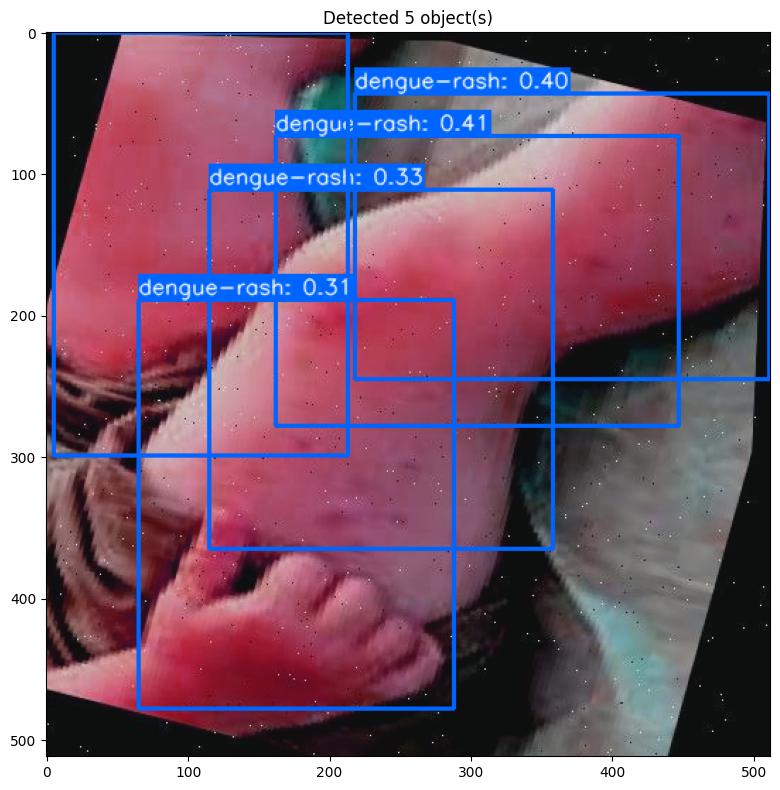

array([[[13, 14, 14],
        [13, 14, 14],
        [13, 14, 14],
        ...,
        [13, 14, 14],
        [13, 14, 14],
        [13, 14, 14]],

       [[13, 14, 14],
        [13, 14, 14],
        [13, 14, 14],
        ...,
        [13, 14, 14],
        [13, 14, 14],
        [13, 14, 14]],

       [[13, 14, 14],
        [13, 14, 14],
        [13, 14, 14],
        ...,
        [13, 14, 14],
        [13, 14, 14],
        [13, 14, 14]],

       ...,

       [[13, 14, 14],
        [13, 14, 14],
        [13, 14, 14],
        ...,
        [13, 14, 14],
        [13, 14, 14],
        [13, 14, 14]],

       [[13, 14, 14],
        [13, 14, 14],
        [13, 14, 14],
        ...,
        [13, 14, 14],
        [13, 14, 14],
        [13, 14, 14]],

       [[13, 14, 14],
        [13, 14, 14],
        [13, 14, 14],
        ...,
        [13, 14, 14],
        [13, 14, 14],
        [13, 14, 14]]], dtype=uint8)
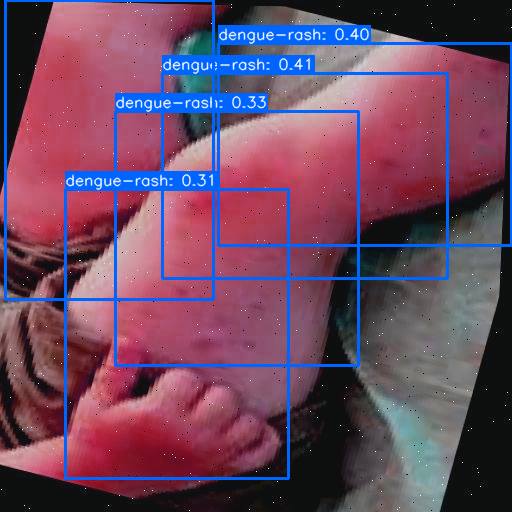

In [75]:
model.eval()
anchors_tensor_cpu = torch.tensor(anchors, dtype=torch.float32)  # CPU cho decode
images, _ = next(iter(train_loader))
img = images[0].to(device)

with torch.no_grad():
    pred = model(img.unsqueeze(0))[0].cpu()
    # (A, 5+cls, S, S)

anchors = torch.tensor(anchors)

# decode
boxes = decode_prediction(pred, anchors, conf_thres=0.3)
print(f"Detected {len(boxes)} boxes before NMS")

# NMS
boxes = nms(boxes, iou_thres=0.5)
print(f"Detected {len(boxes)} boxes after NMS")

# vẽ lên ảnh gốc (đã denormalize)
draw_on_original(images[0], boxes, label_to_name=train_dataset.label_to_name)

Confidence stats:
  Min: 0.0008
  Max: 0.4121
  Mean: 0.0750
  Median: 0.0453
  Boxes > 0.5: 0
  Boxes > 0.7: 0
  Boxes > 0.9: 0


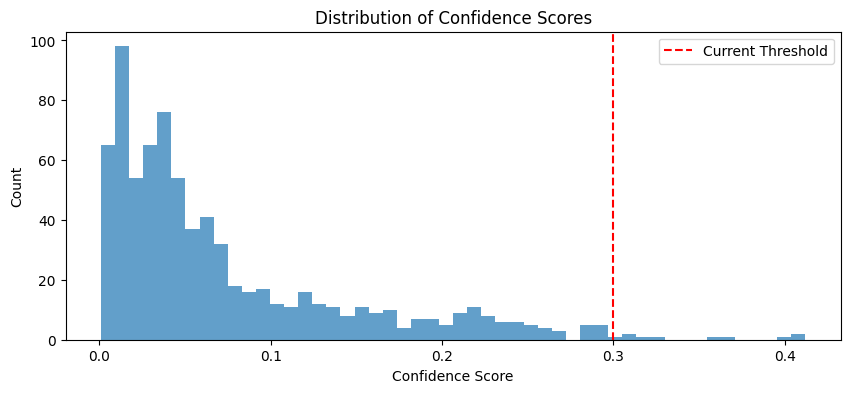

In [76]:
# Thêm code debug để xem phân phối confidence
def analyze_predictions(pred, anchors):
    A, S, _, _ = pred.shape

    pred_obj = torch.sigmoid(pred[..., 4])
    all_confs = pred_obj.flatten().cpu().numpy()

    print(f"Confidence stats:")
    print(f"  Min: {all_confs.min():.4f}")
    print(f"  Max: {all_confs.max():.4f}")
    print(f"  Mean: {all_confs.mean():.4f}")
    print(f"  Median: {np.median(all_confs):.4f}")
    print(f"  Boxes > 0.5: {(all_confs > 0.5).sum()}")
    print(f"  Boxes > 0.7: {(all_confs > 0.7).sum()}")
    print(f"  Boxes > 0.9: {(all_confs > 0.9).sum()}")

    # Plot histogram
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 4))
    plt.hist(all_confs, bins=50, alpha=0.7)
    plt.xlabel('Confidence Score')
    plt.ylabel('Count')
    plt.title('Distribution of Confidence Scores')
    plt.axvline(0.3, color='r', linestyle='--', label='Current Threshold')
    plt.legend()
    plt.show()

# Chạy phân tích trước khi decode
with torch.no_grad():
    pred = model(img.unsqueeze(0))[0].cpu()
    analyze_predictions(pred, anchors_tensor_cpu)
